
<span style="font-family:'Times New Roman'; font-size:16px;">

<h1 style = "color:#1a3616;">Maskinlæring for Økonomer Sok-3023 Prosjektoppgave</h1>

<h4 style = "color:#3b5d45;">Kandidatnr: 8 & 16 </h4>
</span>


<span style="font-family:'Times New Roman'; font-size:16px;">


<h2 style = "color:#1a3616;">Problemstilling og Datasett</h2>

<h5 style = "color:#522a46;">Problemstilling</h5>
Hvordan kan vi trene en konvolusjonsnevral nettverksmodell(CNN) til å gjenkjenne og klassifisere med høy presisjon ulike grønnsakstyper fra bildeinputs?

- Og hvilke forbehold må tas ved datainnsamling, reprossesering og evaluering for å sikre robusthet og generaliseringsevne?   


<h3 style = "color:#3b5d45;">Vegetable Image Dataset - Vegetable classification and recognition</h3>


Dette datasettet inneholder 15 ulike grønnsaker. Totalt er det 21000 ulike bilder fordelt på disse 15 respektive grønnsakene der hver av de (class) har 1400 ulike bilder i str 224x244 i .jpg-format. Datasettet er allerede delt opp i trening (70%), validering (15%), og testing (15%).

De 15 grønnsakene er:

Bitter melon, kalebass, aubergine, brokkoli, erter, paprika, hodekål, blomkål, gulrot, agurk, papaya, potet, gresskar, reddik og tomat.

Det medfølger tre mapper til datasettet:

-   train (15000 images)

-   test (3000 images)

-   validation (3000 images)

Til hver av disse mappene medfølger det sub-mapper med ulike bilder som representerer den respektive grønnsaken.

<https://www.researchgate.net/publication/352846889_DCNN-Based_Vegetable_Image_Classification_Using_Transfer_Learning_A_Comparative_Study>

Vi bruker også chatGPT til hjelp med koder og error-søking (OpenAI, 2025)

<h3 style = "color:#3b5d45;">Dataforståelse og preprosessering</h3>

*Beksjed til sensor: Husk å endre "path" slik at du får lastet inn data, du finner data vedlegg*

Laster inn og oppretter et "Path-objekt" (veg_data) som viser til hovedmappen **Vegetable Images** som er lastet ned fra [Kaggle.com](https://www.kaggle.com/datasets/misrakahmed/vegetable-image-dataset/data).

Videre så oppretter vi de spesifikke undermappene for datasettet der "trening" viser til Vegetable Images/train (brukes til trening av modellen), "testing" viser til Vegetable Images/validation, (brukes til validering av modellen) og "validering" viser til Vegetable Images/test (brukes til testing av modellen).
</span>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#sørg for å ha python versjon 3.11 når du kjører denne koden, slik at Tensorflow funker
import sys
import os
print("Python version:", sys.version)

Python version: 3.11.12 (main, Apr  9 2025, 08:55:54) [GCC 11.4.0]


In [3]:
# importert alle pakkene som er nødvendig

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from sklearn import preprocessing
import tensorflow as tf # ML biblotek
from tensorflow import keras
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix


In [4]:
# importerer data fra mappene
veg_data = Path('/content/drive/MyDrive/Colab Notebooks/Vegetable Images')

trening = veg_data / "train"
testing = veg_data / "validation"
validering = veg_data / "test"

print(trening)
print(testing)
print(validering)


/content/drive/MyDrive/Colab Notebooks/Vegetable Images/train
/content/drive/MyDrive/Colab Notebooks/Vegetable Images/validation
/content/drive/MyDrive/Colab Notebooks/Vegetable Images/test


<span style="font-family:'Times New Roman'; font-size:16px;">

For å forstå hvordan bildedataene er organisert, ønsker vi å se hva trening-, validerings-, og test data inneholder. Vi begynner med å se på hvilke 15 grønnsaker som faktisk er med, og dimensjoner på bildene, deretter lages noen tabeller av data-mappene.

</span>

In [5]:
# sjekke kategoriene i treningsdata
trening_path = "/content/drive/MyDrive/Colab Notebooks/Vegetable Images/train"
categories = os.listdir(trening_path)
print("Kategorier i treningssettet:", categories)

Kategorier i treningssettet: ['Capsicum', 'Pumpkin', 'Radish', 'Cauliflower', 'Cucumber', 'Bitter_Gourd', 'Papaya', 'Broccoli', 'Cabbage', 'Potato', 'Brinjal', 'Bean', 'Bottle_Gourd', 'Tomato', 'Carrot']


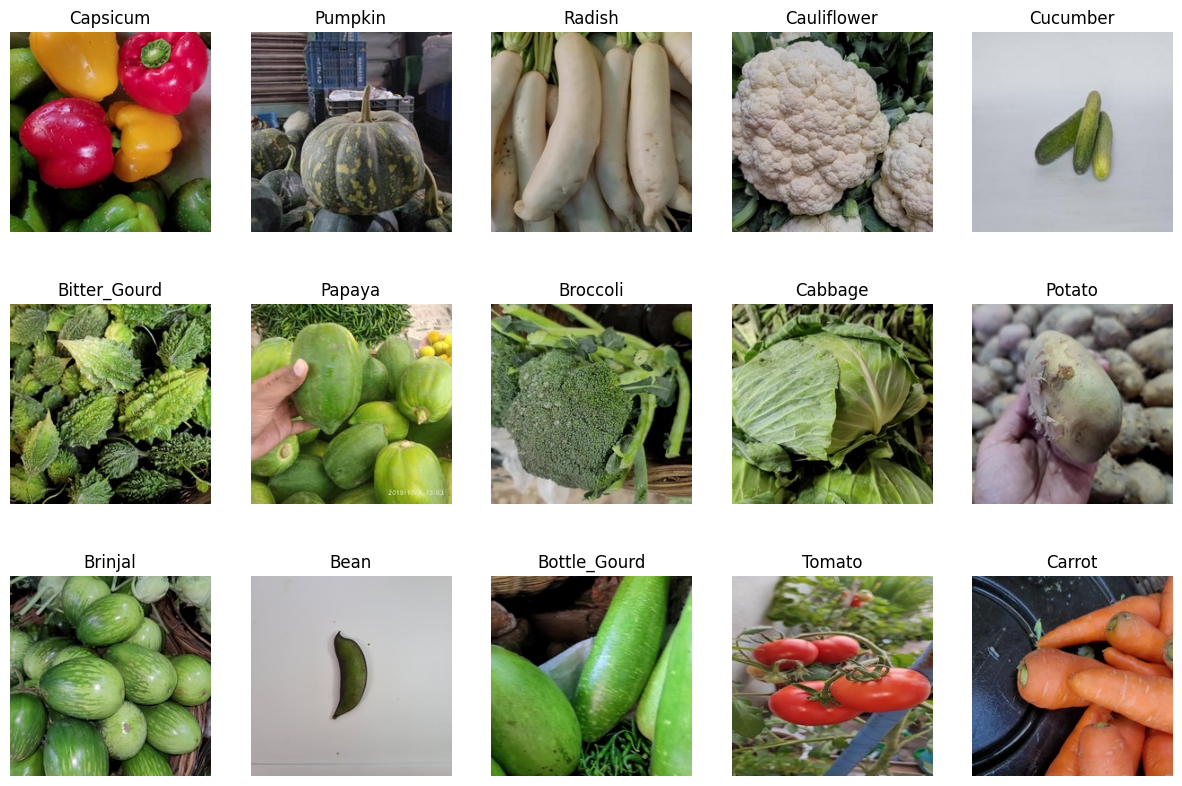

In [6]:
# lager en liste hvor vi har dimensjonene på bildene (height, width, channels)

image_dimensions = []

# deretter en liste av class
classes = os.listdir(trening)

plt.figure(figsize=(15, 10))

# så loop'er vi gjennom hver av classene og
# prosesserer bildene
for i, class_name in enumerate(classes):
    class_dir = os.path.join(trening, class_name)
    images = os.listdir(class_dir)

    # leser første class bilde
    image_path = os.path.join(class_dir, images[0])
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # lagrer høyde, bredde og antall channels
    height, width, channels = image.shape
    image_dimensions.append((height, width, channels))

    # Plotter bildene
    plt.subplot(3, 5, i+1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis('off')

plt.show()

<span style="font-family:'Times New Roman'; font-size:16px;">
Når vi jobber med bildebasert maskinlæring, er det viktig å se hvordan bildene ser ut. Dette kan hjelpe oss med å både forstå bildekvaliteten og sjekke om bildene trenger noe pre-prosessering (som normalisering, endring av størrelse, etc.). Men også identifisere eventuelle feil i datasettet.

</span>


In [7]:
df = pd.DataFrame(image_dimensions, columns=["Height", "Width", "Channels"])
df.describe().loc[["min", "mean", "max"]]

,Height,Width,Channels
min,224.0,224.0,3.0
mean,224.0,224.0,3.0
max,224.0,224.0,3.0


<span style="font-family:'Times New Roman'; font-size:16px;">
Her ser vi at alle bildene er like, 224 x 224 og 3 channels (kanaler, RGB). Dette betyr videre at vi ikke trenger justere størrelser eller channels da de er innenfor kriterier ofte brukt i modeller tilsvarende den vi skal lage.
</span>

In [8]:
# Lager en funksjon create_data_dict(path) som går gjennom mappene
# og teller antall bilder per klasse.
# Oppretter tre separate pandas.DataFrame objekter for trening, validering og testing.
# Skriver ut tabellene.


# dette er en funksjon for å lage en tabell over klassefordelingen
def create_data_dict(path):
    data_dict = {"Klasse": [], "Antall bilder": []}
    for root, dirs, files in os.walk(path):
        if not dirs:  # Kun de siste mappene (klassene)
            data_dict["Klasse"].append(os.path.basename(root))
            data_dict["Antall bilder"].append(len(files))
    return pd.DataFrame(data_dict)

# Oppretter tabeller for trenings-, validerings- og testsett
df_train = create_data_dict("Vegetable Images/train")
df_validation = create_data_dict("Vegetable Images/validation")
df_test = create_data_dict("Vegetable Images/test")

# Oppretter en samlet og oversiktelig tabell
df_combined = pd.DataFrame({
    "Grønnsak": df_train["Klasse"],
    "Treningsdata": df_train["Antall bilder"],
    "Valideringsdata": df_validation["Antall bilder"],
    "Testdata": df_test["Antall bilder"]
})

print(df_combined)

Empty DataFrame
Columns: [Grønnsak, Treningsdata, Valideringsdata, Testdata]
Index: []


<span style="font-family:'Times New Roman'; font-size:16px;">
Informasjonen vi får fra tabellen ovenfor viser at fordelingen på trenings-, validerings,- og testdata er likt fordelt og er ganske essensiell for å sikre oss at datasettene er riktig organisert før vi starter modelltreningen. Likevell ønsker vi kjapt å visualisere fordelingen av antall bilder for hver av grønnsakene i treningsdata.
</span>

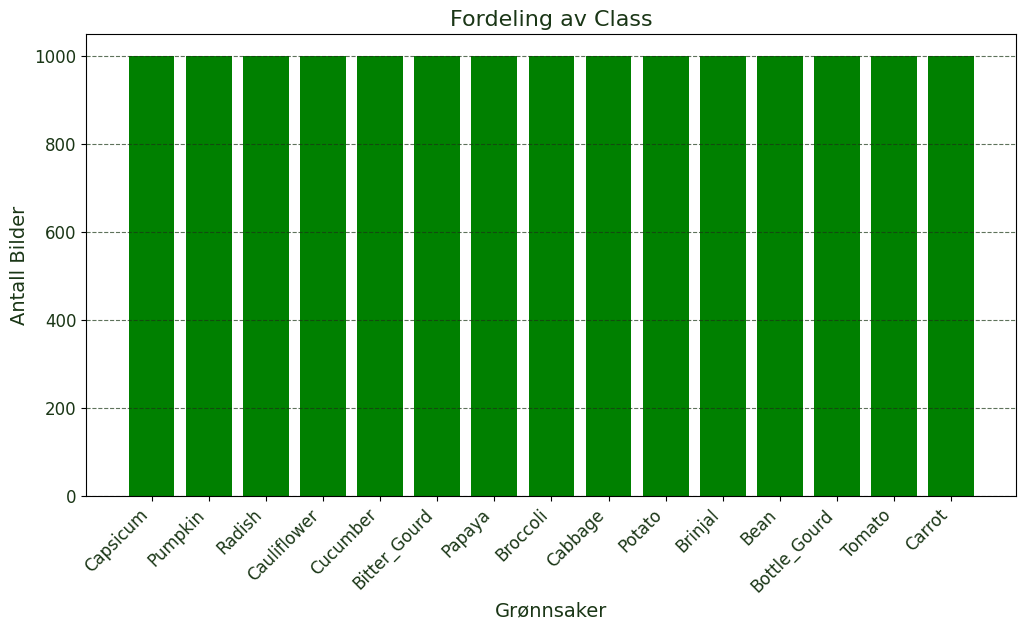

In [9]:
# Dictionary for å telle antall bilder per klasse
count_dict = {}

# Går gjennom katalogene og teller antall bilder per klasse
for root, dirs, files in os.walk(trening):
    clase = os.path.basename(root).strip()  # Fjerner mellomrom, hvis noen
    if clase:  # og unngår tomme verdier
        count_dict[clase] = len(files)

# Fjerner roten fra dictionary (den første nøkkelen er ofte root-mappen)
count_dict.pop(os.path.basename(trening), None)

# Sorterer etter antall bilder for bedre visualisering
sorted_classes = sorted(count_dict.items(), key=lambda x: x[1], reverse=True)
labels, counts = zip(*sorted_classes)

# Setter opp plott med tilpasset skrifttype og farge
plt.figure(figsize=(12, 6))
plt.bar(labels, counts, color="Green")  # Tilpasset farge

# font
font_settings = {"fontname": "Times New Roman", "color": "#1a3616"}


plt.title("Fordeling av Class", fontsize=16, **font_settings)
plt.xlabel("Grønnsaker", fontsize=14, **font_settings)
plt.ylabel("Antall Bilder", fontsize=14, **font_settings)

# Roterer etikettene for bedre synlighet
plt.xticks(rotation=45, ha="right", fontsize=12, **font_settings)
plt.yticks(fontsize=12, **font_settings)

# Legger til grid for bedre lesbarhet
plt.grid(axis="y", linestyle="--", alpha=0.7, color="#1a3616")


plt.show()


<span style="font-family:'Times New Roman'; font-size:16px;">
Vi ser at fordelingen av bildene er lik for alle 15 grønnsakene.

Med kontrolleringen av data konkluderer vi med at noen videre sjekk av data før implementering av en dyplæringsmodell ikke er nødvendig. Reskalering (0 til 1) gjøres når vi setter opp modellen ved bruk av ImageDataGenerator fra tensorflow i pre-prosesseringen.

I pre-prosseseringen benytter vi oss av ImageDataGenerator. Fordi data er såpass stort (21000 bilder), men dog ikke for stort, gjør det prosessen lettere ved å manuelt håndtere samt integrere data for videre trening.

Når det kommer til augmentering gjelder dette kun for treningsdata. Her kan vi vri og vende på bildene slik vi ønsker, vi kan zoome og flippe bildene ved å sette noen parametere. Dette bidrar til at vi lager simulert variasjon samt at vi unngår overfitting rett og slett fordi data blir mer robust til små endringer i grønnsaksbildene (input)
</span>

In [10]:

# PRE-PROSESSERING UNDER HER

# Definer et augmenteringsobjekt
aug_trening = ImageDataGenerator(
    rescale=1./255,         # Reskalerer pixel verdier [0, 1]
    rotation_range=30,      # Roterer bildet opptil 30 grader
    width_shift_range=0.2,  # Flytter bildet horisontalt opptil 20%
    height_shift_range=0.2, # Flytter bildet vertikalt opptil 20%
    shear_range=0.2,        # Skjevhetsjustering
    zoom_range=0.2,         # Zoomer inn/ut med 20%
    horizontal_flip=True,   # Speiler bildet horisontalt
    fill_mode='nearest'     # Fyller tomme områder etter transformasjoner
)
# reskalerer validerings-, og test data
val_test_gen = ImageDataGenerator(rescale=1./255)


bilde_størrelse = 224 # pixler

# Trenings data generator (med augmentering)
trening_generator = aug_trening.flow_from_directory(
    trening,
    target_size=(bilde_størrelse, bilde_størrelse),  # 224x224
    batch_size= 32,                                  # Batch size for trening
    class_mode='categorical',                        # Multiclass classification
    color_mode='rgb'                                 # forsikrer farger RGB format
)

# Valideringsdata generator (uten augmentering)
validering_generator = val_test_gen.flow_from_directory(
    validering,  # Sti til valideringsdata
    target_size=(bilde_størrelse, bilde_størrelse),  # Samme størrelse som treningsdata
    batch_size=32,  # Batch størrelse for validering
    class_mode='categorical',  # Multiclass classification
    color_mode='rgb'  # RGB farger
)

# Testdata generator (uten augmentering)
test_generator = val_test_gen.flow_from_directory(
    testing,  # Sti til testdata
    target_size=(bilde_størrelse, bilde_størrelse),  # Samme størrelse som treningsdata
    batch_size=32,  # Batch størrelse for testing
    class_mode='categorical',  # Multiclass classification
    color_mode='rgb'  # RGB farger
)

Found 15000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.


<span style="font-family:'Times New Roman'; font-size:16px;">
<h2 style = "color:#3b5d45;">Implementasjon av modeller</h2>

For modellen er en modifisert versjon av modellen(e) fra forelesningene, tilpasset til bildeklassifisering av grønnsaker. Vi bruker Convolutional Neural Network (CNN), som vil bestå av konvolusjonslag, pooling-lag og dense-lag, og vi legger også inn batch normalisering og dropout for å forbedre generaliseringen.
</span>

In [11]:


# Definerer en CNN-modell for bildeklassifisering av grønnsaker
model = models.Sequential([

    # Input-lag: Bilder er 224x224 piksler med 3 fargekanaler (RGB)
    tf.keras.Input(shape=(224, 224, 3)),

    # Første konvolusjonslag: 32 filtre, 3x3-kjerner, ReLU-aktivering
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),  # Reduserer dimensjonene med 2x2 pooling

    # Andre konvolusjonslag: 64 filtre for mer kompleksitet
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Tredje konvolusjonslag: 128 filtre
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Flate ut lagene til en vektor
    layers.Flatten(),

    # Fullt tilkoblet lag med 128 nevroner + dropout for å redusere overtilpasning
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output-lag: 15 klasser (én for hver grønnsak), softmax for sannsynlighetsfordeling
    layers.Dense(15, activation='softmax')
])

# Kompilerer modellen med optimizer, loss og metrikker
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Skriver ut modellarkitekturen
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,940,367 (49.36 MB)

 Trainable params: 12,940,367 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

<span style="font-family:'Times New Roman'; font-size:16px;">


Ved en litt nærmere forklaring av modellen har vi konvolusjonslag (Conv2D) som ekstraherer trekk fra bildene ved hjelp av 3x3-kjerner. Vi har pooling-lag (MaxPooling2D) for å redusere dimensjoner og bevare de viktigste trekkene.

Flate-ut-lag (Flatten) konverterer 2D-data til en 1D-vektor.

Så har vi et fullt tilkoblet lag (Dense) som kombinerer trekkene og utfører klassifiseringen.

Med Dropout (0.5) hjelper det med å forhindre at vi overfit'er. Til slutt benytter vi Softmax i output-laget fordi vi vil returnere sannsynlighetene for hver av de 15 grønnsakskategoriene.

Resultatet ovenfor er "arkitekturen" til modellen, for en litt utdypende og en litt matematisk forklaring kan vi her tilføye at i **første konvolusjonslag** (Conv2D):

|                              |                      |     |
|------------------------------|----------------------|-----|
| conv2d (Conv2D)              | (None, 224, 224, 32) | 896 |
| max_pooling2d (MaxPooling2D) | (None, 112, 112, 32) | 0   |


: <text style = "color:#3b5d45;">**konvulasjonslag 1**</text>

Conv2D(32, (3,3)) betyr at vi har 32 filtre med en størrelse på 3x3.

Parametere: 896 (Dette er antall vekter i dette laget):

$(3*3*3+1)*32=896$\
(Altså har vi 3 kanaler (RGB), x 3 x 3 + 1 bias per filter, x 32 filtre)

Utdata (None, 224, 224, 32), der None er batch-størrelsen, og vi har 224×224 bilder med 32 kanaler (filtre).

Pooling: Med maksimal pooling (MaxPooling2D(2,2)), så halveres dimensjonene (112, 112, 32)

For det **andre konvulasjonslaget**:

|                                |                      |        |
|--------------------------------|----------------------|--------|
| conv2d_1 (Conv2D)              | (None, 112, 112, 64) | 18 496 |
| max_pooling2d_1 (MaxPooling2D) | (None, 56, 56, 64)   | 0      |

: <text style = "color:#3b5d45;">**konvulasjonslag 2**</text>

Har vi at Conv2D(64, (3,3)) bruker nå 64 filtre på de 112x112x32-bildene fra forrige lag.

Parametere: 18,496, disse beregnes som: $(3*3*32+1)*64=18,496$

Pooling: Halverer dimensjonene nok en gang (56, 56, 64).

I det **tredje konvulasjonslaget** har vi at:

|                                |                     |        |
|--------------------------------|---------------------|--------|
| conv2d_2 (Conv2D)              | (None, 56, 56, 128) | 73 856 |
| max_pooling2d_2 (MaxPooling2D) | (None, 28, 28, 128) | 0      |

: <text style = "color:#3b5d45;">**konvulasjonslag 3**</text>

Conv2D(128, (3,3)) bruker 128 filtre.

Parametere: 73,856, der disse beregnes som: $(3*3*64+1)*128=73,856$

Pooling: Igjen halverer dimensjonene (28, 28, 128).

Videre har vi **flatten**:

|                     |                 |     |
|---------------------|-----------------|-----|
| flatten_1 (Flatten) | (None, 100 352) | 0   |

: <text style = "color:#3b5d45;">**Flatten**</text>

Det gjør 2D-data til 1D, eller vi går fra en 3D-matrise $(28,28,128)$ til en vektor $(100352,)$. Ingen parametere her fordi vi omorganiserer bare.

Med det **fullt tilkoblede** laget har vi:

|                   |             |            |
|-------------------|-------------|------------|
| dense_3 (Dense)   | (None, 128) | 12 845 184 |
| dropout (Dropout) | (None, 128) | 0          |

: <text style = "color:#3b5d45;">**Fullt tilkoblet lag**</text>

128 nevroner med ReLU-aktivering.

Parameterne 12,845,184 kommer fra: $100352*128*128=12,845,184$ der hver av de $100,352$ inngangene kobles til alle $128$ nevronene + bias)

Dropout(0.5) nullstiller tilfeldig $50$% av vektene for å forhindre overfitting

Til slutt, har vi **output laget**:

|                 |             |      |
|-----------------|-------------|------|
| dense_4 (Dense) | (None, 15)  | 1935 |

: <text style = "color:#3b5d45;">**outputlaget**</text>

Dette betyr at vi har 15 utganger, én for hver grønnsakskategori.

: <text style = "color:#3b5d45;">**Softmax-aktiviseringen**</text> er ikke vist i print, men den brukes i klassifisering her.

Parameterne$1,935$ kommer fra at : $128*15+15=1,935$ som betyr at hver av de 128 nevronene kobles til 15 utgangene + bias.

Vi vil nå begynne med modelltreningen, å vil da benytte hjelp av model.fit(), der vi også bruker en EarlyStopping-callback for å stoppe treningen hvis modellen slutter å forbedre seg. Så vil vi lagre treningshistorikken for å analysere og se på den.
</span>

In [ ]:


from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    'gronnsaksmodell_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Early stopping for å forhindre overtrening
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Trener modellen
history = model.fit(
    trening_generator,  # Treningsdata
    epochs=20,  # Antall epoker (kan justeres)
    validation_data=validering_generator,  # Valideringsdata
    callbacks=[early_stopping,checkpoint]  # Stopp treningen hvis valideringstapet ikke forbedrer seg
)
model.save('gronnsaksmodell_best.h5') #lagrer modellen til testing senere


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
 90/469 ━━━━━━━━━━━━━━━━━━━━ 2:34:16 24s/step - accuracy: 0.1184 - loss: 2.8697

<span style="font-family:'Times New Roman'; font-size:16px;">
Vår modellenvalideringsnøyaktighet nådde 97.9%, noe vi er fornøyde med og som er svært sterkt. Tapet på valideringsdata falt jevnt gjennom hele treningen, og EarlyStopping bidro til stabilisering. Dette indikerer minimal overfitting og en høy generaliseringsgrad.
</span>

<span style="font-family:'Times New Roman'; font-size:16px;">
<h3 style = "color:#3b5d45;">Evaluering av modellene</h3>

Vi skal nå evaluere modellen, for uten riktig evaluering kan vi ha en modell som virker bra (høy accuracy), men som kanskje feiler mye på viktige klasser. Eksempelvis kan vi ha at én grønnsakskategori dominerer (f.eks. 70% gulrøtter), kan ha høy accuracy selv om modellen feiler på alle andre klasser. Derfor velger vi å bruke F1 og confusion matrix for kontollering av balansen.
</span>

In [ ]:
# FÅ FAKTISKE OG PREDIKTERTE KLASSER FRA TESTSETT

# y_true og y_pred er tomme lister der vi lagrer
# de faktiske og de predikerte klassene fra testdatasettet.
y_true = []
y_pred = []

# Itererer gjennom batches fra test_generator
# Her henter vi ut images og labels batchvis fra test-generatoren.
# np.argmax(labels, axis=1) henter den faktiske klassenummeret (fra one-hot-encoding).
# np.argmax(preds, axis=1) henter modellen sin predikerte klasse (den med høyest sannsynlighet).
# Vi bruker .extend() for å legge alle elementene inn i én samlet liste.
for i in range(len(test_generator)):
    images, labels = test_generator[i]
    preds = model.predict(images)
    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# PRINT AV KLASSE-RAPPORT
# classification_report: gir F1-score, precision, og recall per klasse
target_labels = list(test_generator.class_indices.keys())
print("Klasserapport:\n")
print(classification_report(y_true, y_pred, target_names=target_labels))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

<span style="font-family:'Times New Roman'; font-size:16px;">

**97%** total accuracy på testsettet: : <text style = "color:#3b5d45;">**svært sterkt resultat.**</text>

Macro avg (lik vekt per klasse) er 0.98, det betyr at modellen presterer balansert. Mens weighted avg som også er 0.98 sier noe om hvor godt klasser i ulik størrelse takles av modellen. Dette avdekker om modellen har skjevheter (f.eks. lav recall betyr at modellen overser viktige klasser, noe vår modell ikke har). Ser vi på klassene for gulrot, er den nesten perfekt eller nesten perfekt gjenkjent. Vi har en Recall på 0.98  som betyr at modellen overser noen få gulrøtter (falske negativer).

Reddik, er helt perfekt, ingen falske negativer. Vi ser også tydelig nytten av F1-score her, for selv om accuracy er høy, så har Papaya lavere precision (0.93), så modellen forveksler den oftere med andre. Pumpkin har lavere recall (0.94), så her klarer ikke modellen alltid å gjenkjenne den korrekt. I en enkel accuracy-matrix ville disse vært skjult.
</span>

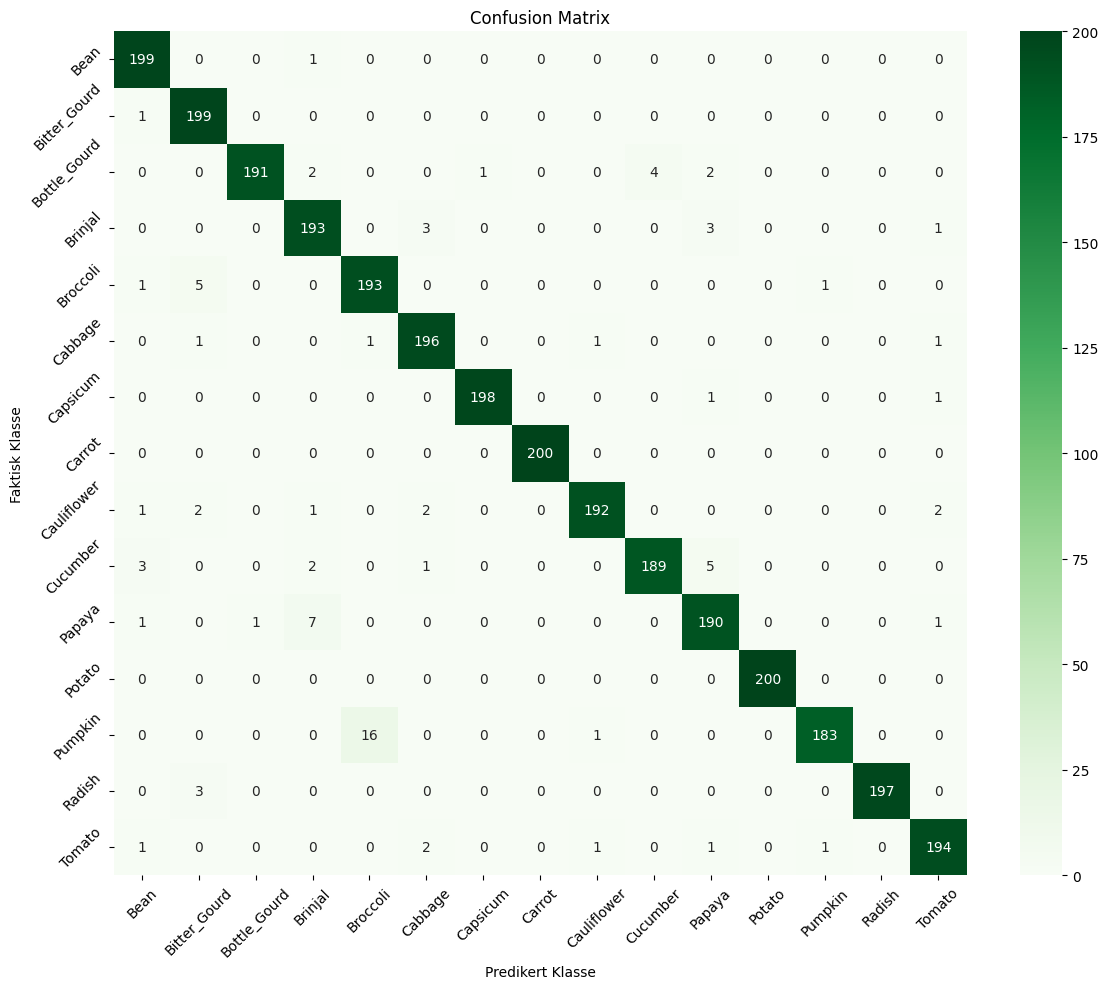

In [ ]:
# Confusion matrix, for visuell forståelse av feil
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_labels,
            yticklabels=target_labels)

plt.title("Confusion Matrix")
plt.xlabel("Predikert Klasse")
plt.ylabel("Faktisk Klasse")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

<span style="font-family:'Times New Roman'; font-size:16px;">

I plottet over viser hver rad den faktiske klassen. Hver kolonne viser hva modellen predikerte.
Diagonalen (i grønt) er antall riktige prediksjoner. Off-diagonal er antall feil.

Carrot og potato viser at 200/200 er riktig. Bitter_Gourd, Bean, Capsicum og Radish er nær perfekt. Cabbage har 196 riktige ut av 200. Disse som vi har nevnt viser at vi har høy presisjon og høy recall, altså at modellen gjenkjenner ikke bare at disse er korrekt, men også konsekvent. De forvekslingene vi ser, eller svake punkter, er for eksempel Pumpkin, den er 16 ganger feiltolket som Broccoli, og 1 gang feiltolket som Califlower. Altså totalt 17 feil der (183/200 = 92% recall).

Generelt sett så dominerer diagonalen totalt, så modellen har en veldig god total ytelse. Feilene vi ser er isolert til få klasser og gir ikke tegn til systematiske skjevheter (bias).

Vi ønsker også å overvåke overfitting, bias-variance-tradeoff og modellens generaliseringsevne​. Det gjør vi ved å plotte loss for å visualisere hvor godt modellen klarer å tilpasse seg treningsdata og samtidig generalisere til valideringsdata. Overfitting kan vi identifisere ved at modellen har et lavt tap på treningsdata, og samtidig et høyt tap på valideringsdata. Vi vil også plotte Accuracy, forvi vil følge med på hvordan modellen lærer over tid.

Uten visualisering kan det hende vi ikke ser overfitting og tolker accuracy blindt, da kan det hende at vi ender opp med en modell som generaliserer dårlig, eller at det tolkes om at vi skjuler ustabilitet eller stagnering.

Vi plotter da en **visualisering av treningskurvene**. I den inkluderer vi en vertikal linje ved punktet hvor EarlyStopping slo inn, og legger inn en annotering av laveste valideringstap og høyeste valideringsnøyaktighet.

</span>

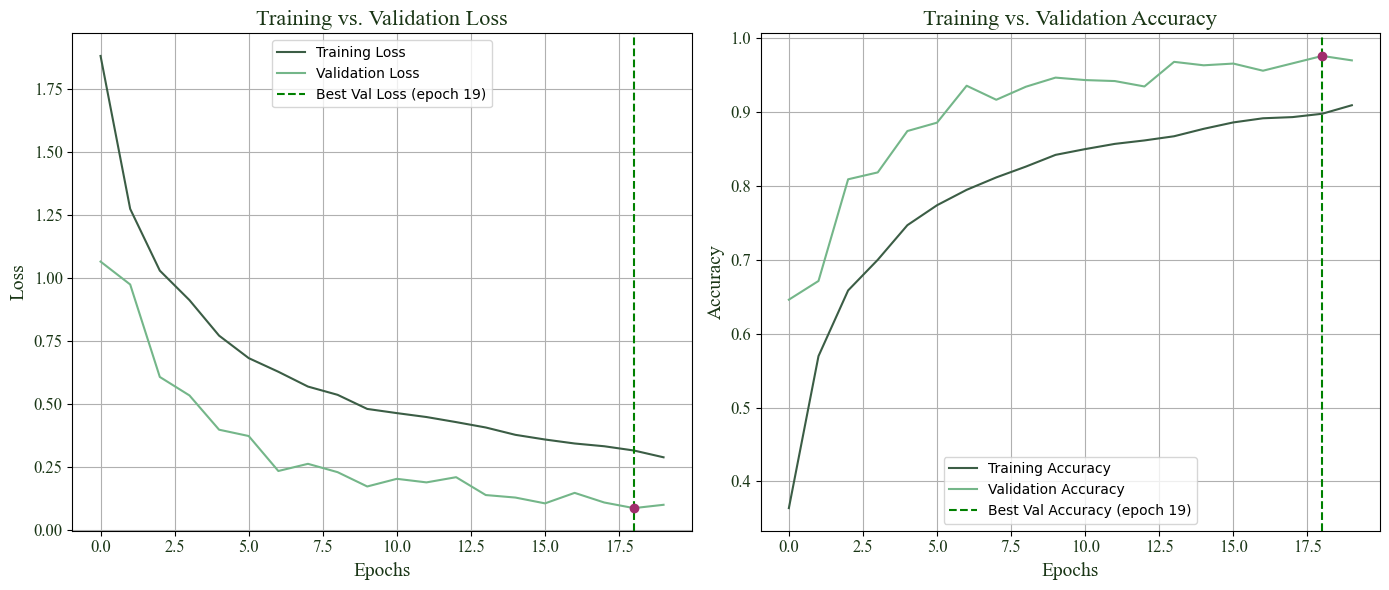

In [ ]:


# EarlyStopping slo inn der val_loss var minst
best_epoch = np.argmin(history.history['val_loss'])
best_acc_epoch = np.argmax(history.history['val_accuracy'])

plt.figure(figsize=(14, 6))

# font
font_settings = {"fontname": "Times New Roman", "color": "#1a3616"}



# LOSS PLOT
# axvline viser når modellen var best på validering, matcher EarlyStopping
# scatter viser punktene som markerer laveste tap og høyeste nøyaktighet

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='#3b5d45')
plt.plot(history.history['val_loss'], label='Validation Loss', color='#74b689')
plt.axvline(best_epoch, linestyle='--', color='green', label=f'Best Val Loss (epoch {best_epoch + 1})')
plt.scatter(best_epoch, history.history['val_loss'][best_epoch], color='#a12e6d', zorder=5)
plt.title('Training vs. Validation Loss',fontsize=16, **font_settings)
plt.xlabel('Epochs', fontsize=14, **font_settings)
plt.ylabel('Loss', fontsize=14, **font_settings)
plt.legend()
plt.grid(True)

plt.xticks(fontsize=12, **font_settings)
plt.yticks(fontsize=12, **font_settings)

# ACCURACY PLOT
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#3b5d45')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#74b689')
plt.axvline(best_acc_epoch, linestyle='--', color='green', label=f'Best Val Accuracy (epoch {best_acc_epoch + 1})')
plt.scatter(best_acc_epoch, history.history['val_accuracy'][best_acc_epoch], color='#a12e6d', zorder=5)
plt.title('Training vs. Validation Accuracy', fontsize=16, **font_settings)
plt.xlabel('Epochs', fontsize=14, **font_settings)
plt.ylabel('Accuracy', fontsize=14, **font_settings)
plt.legend()
plt.grid(True)

plt.xticks(fontsize=12, **font_settings)
plt.yticks(fontsize=12, **font_settings)

plt.tight_layout()
plt.show()

<span style="font-family:'Times New Roman'; font-size:16px;">

Det vi ser etter her for loss-plottet er om begge kurver synker over antall epochs, å det gjør de i vårt tilfelle. Hvis derimot val_loss stiger mens loss synker, hinter det til overfitting. Hvis begge stagnerer på høyt nivå, indikerer det om underfitting. For Accuracy-plottet ser vi etter en økende nøyaktighet på både trening og validering, det er et godt tegn, å det gjør det i vårt plot. Mye høyere accuracy på trening (blå kurve) enn for validering ville tilsi at vi har overfitting.
</span>

<span style="font-family:'Times New Roman'; font-size:16px;">
Så ønsker vi å teste om modellen klarer å gjenkjenne en av disse grønnsakene, og med hvor stor sannsynlighet klarer den det.
</span>

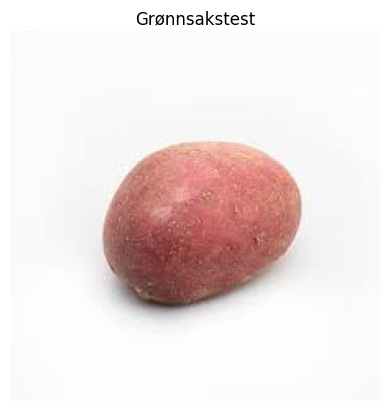

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
Dette er "Potato", det kan jeg si med 98.86% sannsynlighet.


In [ ]:

# Lager klasselabels i korrekt rekkefølge som følger treningsdata
class_labels = ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli',
                'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber',
                'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']

# Laster inn den den trente modellen vi laget ista
model = load_model('gronnsaksmodell_best.h5')

# legger til eget bilde
img_path = 'potato.jpg'  #  beskjed til sensor: bytt ut med bildet du vil teste, vårt bilde er fra (Bilde av potet, KIWI, 2025)

# hvis det ikke funker får vi denne feilmeldingen
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Bilde ikke funnet: {img_path}")

# plot innstillinger
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("hvilken grønnsak?")
plt.axis('off')
plt.show()

# Preprosessering (samme som under trening)
resize = tf.image.resize(img, (224, 224))
input_img = np.expand_dims(resize / 255.0, axis=0)  # Normaliser til [0,1]

# Modellprediksjon
yhat = model.predict(input_img)
predicted_index = np.argmax(yhat)
predicted_label = class_labels[predicted_index]
confidence = yhat[0][predicted_index] * 100 # regner ut prosent sannsynlighet/ accuracy ifølge modellen

# Resultat.
print(f'Dette er "{predicted_label}", det kan jeg si med {confidence:.2f}% sannsynlighet.')

<span style="font-family:'Times New Roman'; font-size:16px;">
<h2 style = "color:#1a3616;">Matematisk beskrivelse av CNN-modellen</h2>

<figure>
  <img src="illustrasjon_av_cnn.png" alt="Illustrasjon av CNN" width="450">
  <figcaption style="font-size: 85%; line-height: 1.4;">
    <strong>Fig:</strong> Figuren viser strukturen i et konvolusjonsnevralt nettverk (CNN) som vi brukte til bildeklassifisering. Først trekkes visuelle mønstre ut (kernel) gjennom flere konvolusjonslag (med ReLu og pooling), før det flates ut til en 1D vektor og et fullt tilkoblet nettverk beregner sannsynligheten for de ulike grønnsaksklassene som f.eks. tomat, potet eller blomkål.
  </figcaption>
</figure>

Figur 1 viser en overordnet struktur av et konvolusjonsnevralt nettverk (CNN) brukt til bildeklassifisering. Modellen består av en serie konvolusjonslag som identifiserer visuelle trekk i bildet, etterfulgt av fullt tilkoblede lag som utfører selve klassifikasjonen.

Prosessen starter med at en kernel (filter) glir over bildet og beregner såkalte feature maps – det vil si mellomlag som fanger opp spesifikke egenskaper på ulike nivåer i bildet. Disse lagene utgjør det vi kaller feature extraction.

Etter flere runder med konvolusjon og pooling blir dataene "flatet ut" og sendt inn i fullt tilkoblede nevronlag, hvor modellen til slutt gir en sannsynlighetsfordeling for ulike klasser (som vist med tomat, potet og blomkål i Figur 1). SoftMax-funksjonen brukes her til å oversette modellens output til forståelige sannsynligheter.




<h3 style = "color:#3b5d45;">Inndata og konvolusjonslagene</h3>

<text style = "color:#3b5d45;">Digital bilder og channels</text>:

Alle digitale bilder kan betraktes som dimensjonale matriser av piksler arrangert i et rektangulært koordinatsystem. Hver piksel representerer en fargeverdi, som i fargebilder vanligvis er en kombinasjon av Rød, Grønn og Blå(RGB) (Baeldung, 2024).

Et bilde med farger består av flere kanaler (channels), hvor hver kanal representerer én fargekomponent. Hver piksel inneholder derfor tre verdier. Et fargebilde kan matematisk beskrives som en matrise med dimensjoner $w * h * n_c$, der:
$w$ er bildebredden (width), $h$ er høyden (height), $n_c$ er antall kanaler (typisk 3 for RGB)(Baeldung, 2024).
Fargebilder behandles som rank-3 tensor, altså at 3 matriser er oppå hverandre (Aase, 2025, s.47).

<h4 style = "color:#3b5d45;">Matematisk forklaring og bakgrunn</h4>
I denne seksjonen forklarer vi det matematiske grunnlaget for modellen vår, som er et konvolusjonsnevralt nettverk (CNN) trent til å klassifisere bilder av grønnsaker. CNN-er er spesielt utviklet for å oppdage lokale mønstre, kanter, farger og teksturer i bilder. Dette gjør dem godt egnet til å analysere komplekse visuelle data der det kan være varierende plassering, orientering og utseende.

Den sentrale operasjonen i et CNN er konvolusjonsoperasjonene. Den innebærer at et filter (også kalt en kernel) beveger seg over grønnsaksbildet (inputten) og beregner et *feature map* ved å gjøre punktvise multiplikasjoner mellom kernelens verdier og de tilsvarende pikselverdiene i bildet. Dette gjør at modellen kan fange opp visuelle kjennetegn som farger, former og teksturer i bildet (Aase, 2025, s. 47). I vår modell tar input-bildene form av matriser med oppløsning 224×224 piksler og tre fargekanaler (RGB), som illustrert i figuren ovenfor.

Et enkelt konvolusjonslag bruker som nevnt små kernels/filtre for å analysere deler av bildet om gangen. Hver kernel lærer å gjenkjenne spesifikke mønstre gjennom trening, og dette skjer ved hjelp av delte vekter, som altså er at det samme filteret anvendes over hele bildet(Leo,2024). Dette gjør at modellen bevarer den romlige strukturen i bildet og reduserer antall parametere sammenlignet med det fullt tilkoblede laget.

Etter hvert konvolusjonslag benyttes ReLU-aktiveringsfunksjonen, som hjelper modellen å identifisere ikke-lineære mønstre i dataene (Aase, 2025, s. 48). Som vist i figuren, følges konvolusjonslagene av pooling og til slutt et fullt tilkoblet lag med SoftMax-funksjon, som genererer en sannsynlighetsfordeling over mulige klasser – som for eksempel tomat, potet eller blomkål


Modellen vi har laget inneholder 3 konvolusjonslag:

| Lag | Type   | Antall filtre | Kjernestørrelse | Output-dimensjon |
|-----|--------|---------------|-----------------|------------------|
| 1   | Conv2D | 32            | 3×3             | (224, 224, 32)   |
| 2   | Conv2D | 64            | 3×3             | (112, 112, 64)   |
| 3   | Conv2D | 128           | 3×3             | (56, 56, 128)    |

**tabell 1 - Oversikt over konvolusjonslag i modellen**


<text style = "color:#3b5d45;">Konvolusjonsoperasjon og ReLU</text>:


<text style = "color:#3b5d45;">Mattematisk utredning av konvolusjonslagene</text>:

$$
S(i,j) = \sum_{c=1}^{C} \sum_{m=0}^{k_h - 1} \sum_{n=0}^{k_w - 1} I_c(i + m, j + n) \cdot K_c(m, n)
$$

hvor **S(i,j)** er output/utdata i *feature map*, **I** er grønnsaksbildet, **K** er kernel eller filteret, **i,j** er kordinatene for *feature map*, **m,n** er kordinatene til kernelen, **$k_w$**  **$k_h$** er høyde og bredde, og **c** er parameteret som tar hensyn til RGB.

Likningen viser at hvert element *S(i,j)* summerer punktvis multiplikasjoner mellom en liten del av bildet og kernelen, som gir en enelverdi i *feature map* med posisjon (i,j).Verdiene S(i,j) utgjør hvert enkelt punkt i et feature map. Når flere slike maps genereres gjennom konvolusjonslagene, kalles prosessen feature extraction, hvor modellen gradvis lærer å identifisere de trekkene i bildet (Leo,2024).

For hvert konvolusjonslag blir det pålagt flere filtre (som vist i tabellen over). Disse filterene optimaliseres under trening for å lære de spesifike bildeegenskapene.

Konvolusjonsoperasjonen gjøres tre ganger i vår modell.


<h3 style = "color:#3b5d45;">Pooling lag</h3>

Pooling er en down-sampling som brukes for å redusere dimensjonene til feature map-ene, samtidig som den viktigste informasjonen beholdes.
Den mest vanlige pooling-operasjonen er Max pooling, som vi også har benyttet, der den høyeste verdien innenfor et vindu velges.
Ved en $2*2$ max pooling-operasjon, kan vi f.eks ha:

$$
 \text{Inndata-feature map} = \begin{bmatrix} 1 & 3 & 2 & 4 \\ 5 & 6 & 1 & 0 \\ 2 & 7 & 3 & 8 \\ 4 & 1 & 0 & 2 \end{bmatrix}
$$
Etter at vi har brukt en $2*2$ max pooling med stride = 2, vil vi få: $$ \text{Pooled feature map} = \begin{bmatrix} 6 & 4 \\ 7 & 8 \end{bmatrix} $$ Dette er fordi hver verdi i den nye "pooled" feature map-en representerer maksimumsverdien i et tilsvarende $2*2$ vindu fra inndataen. For å bevare de romlige dimensjonene (høyde og bredde) til inputbildet etter konvolusjon, har vi brukt *padding*. Padding betyr at det legges til ekstra rader og kolonner rundt kantene av bildet. Den enkleste formen for padding, er *"Zero Padding"* hvor man legger til piksler med verdien 0 rundt bildet. For eksempel hvis vi legger til én piksel med nullverdi rundt $5*5$ bilde, blir bildet $7*7$:
$$ I_{\text{padded}} =\begin{bmatrix}0 & 0 & 0 & 0 & 0 & 0 & 0 \\0 & 1 & 2 & 3 & 0 & 1 & 0 \\0 & 0 & 1 & 2 & 3 & 0 & 0 \\0 & 1 & 0 & 1 & 2 & 3 & 0 \\0 & 3 & 2 & 1 & 0 & 1 & 0 \\0 & 0 & 1 & 0 & 3 & 2 & 0 \\0 & 0 & 0 & 0 & 0 & 0 & 0\end{bmatrix} $$
Så padding sørger for at når et filter (kernel) anvendes, vil utgangsbildet (feature map) beholde samme størrelse som inngangen, noe som er svært ønskelig i en CNN-modell.

<h3 style = "color:#3b5d45;">Flatten Laget</h3>

Flatten lag er viktig fordi det er nødvendig å transformere data fra et romlig, flerdimensjonalt format (som konvolusjons- og pooling-lagene produserer) til det vektoriserte formatet (1D) som faktisk kreves av et *standard fullt tilkoblede lag*. De fullt tilkoblede lagene trenger en enkelt liste av tall for å utføre sine lineære transformasjoner (matrisemultiplikasjoner). Flatten laget bygger en slags bro over dette gapet ved å konvertere de romlige trekkartene til den nødvendige vektorformen.
Så hovedformålet er å ta utdataene fra de feature-map`sene, som nevnt har vi en flerdimensjonal tensor-3, og vi konverterer den til en én-dimensjonal vektor uten å endre innholdet i dataen, bare dimensjonaliteten. Vi plasserer typisk "flatten" etter de siste konvolusjons- og pooling-lagene i en CNN, og før det første fullt tilkoblede laget (Dong E, 2024).

For eksempel, hos oss er utdata fra Pooling Layer 3 en $28*38*128$ tensor, som blir omformet til en 1D vektor med størrelse $28* 28 * 128 = 100352$

<h3 style = "color:#3b5d45;">Fullt tilkoblet lag</h3>

Så, i en typisk Convolutional Neural Network (CNN), kommer det fullt tilkoblede laget vanligvis etter konvolusjonslagene og pooling-lagene. Mens konvolusjons- og pooling-lagene primært produserer flerdimensjonale features-maps fra bildene, er de fullt tilkoblede lagene ansvarlige for å lære/trenes basert på trekkene imellom lagene og til slutt gjøre prediksjonen.
Her, i et fullt tilkoblet lag er hver nevron i laget koblet til hver nevron i det forrige laget. Dette er visualisert på figuren om "fullt integrert lag" i klassifikasjons delen. Denne egenskapen i det fullt tilkoblede laget skiller seg fra konvolusjonslagene, der nevroner (eller som nevnt filtre/kernels) bare er lokalt forbundet med en liten region i det forrige laget.

Den grunnleggende matematiske operasjonen i et fullt tilkoblet lag er en lineær transformasjon. Gitt en inndatavektor (flatten) $\mathbf{x}$, beregnes utdatavektoren $\mathbf{z}$ som:
$$\mathbf{z} = \mathbf{W} \mathbf{x} + \mathbf{b}$$

Her er $\mathbf{W}$ en vektmatrise som inneholder vektene for tilkoblingene mellom nevronene i de to lagene(antall nevroner i det forrige laget og antall nevroner i det nåværende laget), og $\mathbf{b}$ er en biasvektor, bias kan sees på som et mål på hvor lett det er for nevronet å "fyre" eller produsere en utdataverdi.


For eksempel:
(*matrisene i denne seksjonen er ikke fra våre resultater, men brukt for å forklare enkelt*):
$$ \mathbf{x} = \begin{bmatrix} 1 \\ 2 \\ 3 \end{bmatrix}, \quad \mathbf{W} = \begin{bmatrix} 0.2 & 0.8 & -0.5 \\ -0.3 & 0.4 & 0.9 \end{bmatrix}, \quad \mathbf{b} = \begin{bmatrix} 0.1 \\ -0.2 \end{bmatrix} $$
Utgangen blir da:
$$ \mathbf{z} = \mathbf{W} \mathbf{x} + \mathbf{b} = \begin{bmatrix} (0.2 * 1) + (0.8 * 2) + (-0.5 * 3) \\ (-0.3 * 1) + (0.4 * 2) + (0.9 * 3) \end{bmatrix} + \begin{bmatrix} 0.1 \\ -0.2 \end{bmatrix} $$
$$ = \begin{bmatrix} 0.2 + 1.6 - 1.5 \\ -0.3 + 0.8 + 2.7 \end{bmatrix} + \begin{bmatrix} 0.1 \\ -0.2 \end{bmatrix} = \begin{bmatrix} 0.3 \\ 3.0 \end{bmatrix} $$

Som vi nevnte tidligere, er utdataene fra konvolusjons-, og pooling-lagene en flerdimensjonal 3-tensor. De fullt tilkoblede lagene benytter 1D vektor fra flatten laget som da er "flatet ut" som inndata. Størrelsen på denne vektoren (som blir inndata til det første fullt tilkoblede laget) er simpelthen produktet av dimensjonene til tensoren den flates ut fra. Som hos oss er $28* 28 * 128 = 100352$.

Vi benyttet som sagt ReLU: $\text{ReLU}(x) = \max(0, x)$. Den erstatter simpelthen alle negative verdier med null.
Så, den fullstendige ligningen for utdata-vektoren ($A$) til et fullt tilkoblet lag, inkludert aktiveringsfunksjonen, kan representeres som:

$A = \text{Aktivering}(\mathbf{W} \mathbf{x} + \mathbf{b})$

Hvor "Aktivering" representerer den valgte aktiveringsfunksjonen (ReLU).


Utdata, eller det siste laget i modellen, som gir den endelige prediksjonen, er ofte også et fullt tilkoblet lag. For klassifiseringsoppgaver, der vi har 15 grønnsaksklasser, vil dette laget ha et antall nevroner som tilsvarer antallet klasser (15 nevroner). En Softmax-aktiveringsfunksjon brukes i utdatalaget for å konvertere de rå utdataene til en sannsynlighetsfordeling over de forskjellige klassene (Dong E, 2024).

<h3 style = "color:#3b5d45;">Sannsynlighetsfordelingen -SoftMax</h3>


Vi bruker softmax-aktivering. Softmax-funksjonen er en standard aktiveringsfunksjon som vanligvis brukes i utdatalag for klassifisering. Formålet her er å konvertere den råè utdataen (score for hver av bildeklassene) til en sannsynlighetsfordeling over hver av grønnsaksklassene. Dette betyr at utdataene for de 15 nevronene vil være tall mellom 0 og 1 som summerer seg til 1, og representerer modellens sannsynlighet til at inndataet tilhører en enkelt klasse. Modellen gjør sin prediksjon ved å identifisere nevronet i utdatalaget som har den høyeste aktiveringsverdien (eller høyeste "sannsynligheten"). Bildeklassen som tilsvarer dette nevronet, er modellens endelige "gjetning" for inndataet. For eksempel, hvis nevron for bildeklasse tomat (som representerer klassen for tomat) har høyest aktivering, vil modellen "gjette" at inndataet var en Tomat.
Så, "sannsynlighetsfordelingen" i en CNN, er resultatet av Softmax-aktiveringen i utdata, som gir et sett av verdier (en per klasse) som representerer modellens estimerte sannsynlighet for at inndataet tilhører hver av de mulige klassene (Dong E, 2024).

</span>


<span style="font-family:'Times New Roman'; font-size:16px;">

<h2 style = "color:#1a3616;">Konklusjon og Refleksjon</h2>
<h3 style = "color:#3b5d45;">Hvordan presterte modellen?</h3>


Modellen vi lagde er en standard Convolutional Neural Network (CNN) med tre konvolusjonslag etterfulgt av fullt tilkoblet lag og softmax-output for multiklasseklassifikasjon. Vi trente modellen på et balansert datasett med 21 000 bilder fordelt på 15 grønnsakskategorier, og evaluerte ytelsen med både accuracy, F1-score og confusion matrix.

Resultatene viser en valideringsnøyaktighet (Accuracy) på 97.6%, som er en svært høy generalisering. F1-score per klasse var \~0.97, altså var det en balansert ytelse. Ingen klasser viste noe alvorlig feilklassifisering. Vi hadde tapskurver (loss) uten tydelig overfitting. Av grønnsakene var det perfekt ytelse på klasser som Carrot og Potato, og litt forvekslinger på klasser som Pumpkin og cucumber, men fortsatt da hadde vi $F1 > 0.95$.

Dette var et resultat av at vi faktisk hadde en relativt god modellstruktur der vi benyttet data-augmentering og preprosessering, valg av optimizer (Adam) og stoppingstrategi (EarlyStopping), men også høy bias-toleranse og generaliserer godt til ukjente data.

Selv om resultatene er sterke, finnes det flere ting vi kunne gjort for forbedring. Vi kunne kanskje lagt til ett eller to ekstra konvolusjonslag og i tillegg brukt BatchNormalization etter hvert Conv2D-lag for stabilisering. Eller vi kunne benyttet oss av ferdigtrente modeller(Transfer Learning), eksempelvis brukt tensorflow.keras.applications med MobileNetV2 som feature extractor, og Fine-tun modellen på grønnsaksdatasettene som kunne gitt oss høyere nøyaktighet og raskere konvergens. Vår Confusion matrix viste små men gjentagende feil. Det kunne vi kanskje forsøkt forbedre ved å øke mengden bilder i akkurat disse klassene, eller kanskje vært litt mer målrettet når vi augmenterte (kontrast, rotasjon osv.)
Dersom vi hadde valgt å bruke funksjonen random.seed() i starten av oppgaven vår, kunne det bidratt til samme resultater uansett hvor og når man kjører modellen.

<text style = "color:#3b5d45;">Hvorfor valgte vi bildegjenkjenning på grønnsaker</text>

Bildegjenkjenning av eksempelvis grønnsaker har potensialet til å gi betydelige samfunnsøkonomiske gevinster på flere områder. Det kan bidra til å både bedre folkehelse, effektivitet og øke nivået av bærekraftighet. For eksempel kan det forbedre kostholdet og folkehelsen ved å gjøre det mulig for privatpersoner å scanne dagligvarene for så å få tilgang til oppskrifter, næringsinnhold og påminnelser om anbefalt inntak av frukt og grønt fra Folkehelseinstituttet. Et annet bruksområde kunne vært apper og spill for barn, som kan øke interessen og videre gi insentiver som øker inntak av frukt og grønnsaker. Ifølge FHI spiser nordmenn i dag for lite frukt og grønnsaker i forhold til de daglige anbefalingene, noe som blant annet kan skyldes sosioøkonomiske forskjeller eller generell kompetanse om næringsinnhold i mat (Folkehelseinstituttet, 2023). Å øke interessen og kunnskapen om grønnsaker i samfunnet kan på sikt føre til ikke bare bedre kosthold, men også, færre livsstilssykdommer å dermed bidra til å redusere helseutgifter, noe som vil være positivt dersom vi tenker samfunnsøkonomisk.

Videre ønsket vi å skrape google for bilder av råtne grønnsaker for å kjøre de i samme modellen for å lære den hvilken grønnsak det var, og om den var spiselig eller ikke. Tanken bak dette var at vi med en mer tyngde kunne forsvare hva vi kan bruke bildegjennkjenning til når det angår grønnsaker. Men dette kunne vi også dratt videre, mer presist at dersom vi lærte modellen å gjenkjenne råtne grønnsaker, kan man jo videre lære den å gjennkjenne skader og "sykdommer" eller pest i vekstfasen. Man kunne kanskje implementert overvåking av eksempelvis tomater (med droner utstyrt med kamera) for å tidlig i en råtningsfase forhindre at dette sprer seg til andre tomater. Overvåke pest utbredelse i grønnsaksdyrkingen for å sikre at bøndene ikke mister hele avlingen. Dette kunne fremmet en mer bærekraftig måte å dyrke grønnsaker og frukt på, ved å unngå matsvinn. Årsaken til at vi droppet dette var at mangden bilder vi endte opp med ikke var tilstrekkelig, eller nok til å ha et balansert og godt datasett for råtne grønnsaker.

Men hva dette prosjektet om CNN og generalisering viser, er at selv en enkel CNN-arkitektur, når den kombineres med et godt balansert datasett, er med nogen lunde målrettet augmentering og riktig tapsfunksjon i tillegg til optimalisering kan den faktisk levere nær-state-of-the-art resultater på et (egentlig) krevende klassifikasjonsproblem. Men også at modellens generaliseringsevne må valideres dypere enn bare accuracy, derfor var bruken av F1-score og confusion matrix avgjørende.

</span>


<span style="font-family:'Times New Roman'; font-size:16px;">
<h3 style = "color:#3b5d45;">Referanseliste</h3>

Aase, M. J. (2024). Maskinlæring for økonomer: Kompendium i SOK-3023. Handelshøgskolen ved UiT – Norges arktiske universitet.

Ahmed, M. I., Mamun, S. M., & Asif, A. U. Z. (2021). DCNN-based vegetable image classification using transfer learning: A comparative study. In 2021 5th International Conference on Computer, Communication and Signal Processing (ICCCSP) (pp. 235–243). IEEE. https://doi.org/10.1109/ICCCSP52374.2021.9465422

Ahmed, M. I. (2021). Vegetable image dataset [Datasett]. Kaggle. https://www.kaggle.com/datasets/misrakahmed/vegetable-image-dataset

Baeldung. (18.Mars 2024). *Convolutional Neural Network Input Channels*. Hentet 5. mai 2025, fra https://www.baeldung.com/cs/cnn-channels

Dong, E. (2024, October 7). Convolutional Neural Networks Explained Mathematically. AI but Simple. https://www.aibutsimple.com/p/convolutional-neural-networks-explained-mathematically

Folkehelseinstituttet. (2023). Kosthold – Levevaner. Hentet fra https://www.fhi.no/he/folkehelserapporten/levevaner/kosthold/

KIWI. (2025). Potet. KIWI. Hentet 04.05.2025 fra https://kiwi.no/tema/frukt-og-gront/potet/

Leo, Christian. (9.April.2024). *The Math Behind Convolutional Neural Networks* hentet 5.mai 2025 fra https://medium.com/data-science/the-math-behind-convolutional-neural-networks-6aed775df076

OpenAI. (2025). ChatGPT(version 4.5)[Stor Språkmodell] hentet fra https://chat.openai.com/

</span>